# Análise Exploratória — Laboratório de Estresse Semântico

Este notebook explora os resultados da **Fase 1** (deriva espacial de embeddings) do
projeto. A hipótese testada na Fase 1 é: pares (texto original / tradução intralingual
simplificada) marcados por um fenômeno retórico-sintático dominante deveriam ficar
*próximos* no espaço vetorial de um bom modelo de embeddings, já que ambos os textos
foram anotados como semanticamente equivalentes. Baixa similaridade de cosseno é lida
como evidência de "estresse semântico" — o modelo está sendo influenciado mais pela
forma de superfície do que pelo conteúdo proposicional.

**Este notebook é exploratório e investigativo**, não faz parte do pipeline de
produção (`src/embeddings/`). Ele reutiliza a mesma interface de modelos definida em
`src/embeddings/models.py`, mas o código aqui pode ser mais solto: sem testes, sem
tratamento de erro extensivo, com decisões de análise documentadas em texto ao invés
de em código.

**Aviso sobre o tamanho da amostra:** o dataset atual (`dataset_v0.jsonl`) tem apenas
12 pares anotados. Isso é suficiente para uma leitura qualitativa e para levantar
hipóteses, mas é pequeno demais para conclusões estatísticas robustas — isso é
sinalizado explicitamente em cada seção onde é relevante (correlações, testes de
hipótese).

## 1. Setup e carregamento

Carregamos as duas fontes de dados da Fase 1:

- `data/processed/dataset_v0.jsonl`: os textos originais e simplificados, com
  metadados de anotação (autor, obra, fenômeno linguístico, nível de confiança).
- `results/phase1_embeddings/cosine_similarity_by_model.csv`: as similaridades de
  cosseno já calculadas pelo pipeline (`src/embeddings/run_phase1.py`) para os três
  modelos (BGE-M3, LaBSE, EmbeddingGemma), assim não recalculamos o que já existe.

Os dois são unidos (`merge`) pelo campo `id`, que identifica unicamente cada par.

Importa as bibliotecas usadas no notebook e resolve o caminho raiz do projeto, para
que os módulos em `src/` (reaproveitados na Seção 3) possam ser importados
independentemente de o notebook estar sendo executado a partir de `notebooks/` ou da
raiz do repositório.

In [1]:
import json
import os
import sys
from pathlib import Path

# Os três modelos de embedding já estão baixados no cache local do Hugging Face
# (usados pelo pipeline da Fase 1). O EmbeddingGemma é um repo "gated": mesmo com os
# pesos em cache, a lib tentaria uma checagem online e falharia sem um token válido.
# Como não precisamos baixar nada novo aqui, forçamos modo offline.
os.environ.setdefault("HF_HUB_OFFLINE", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind, mannwhitneyu
from sklearn.decomposition import PCA
import umap

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.embeddings.models import BGEM3Model, LaBSEModel, EmbeddingGemmaModel  # noqa: E402

DATA_PATH = project_root / "data" / "processed" / "dataset_v0.jsonl"
SIM_PATH = project_root / "results" / "phase1_embeddings" / "cosine_similarity_by_model.csv"
FIG_DIR = project_root / "results" / "phase1_embeddings" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SIM_COLS = ["similaridade_bge_m3", "similaridade_labse", "similaridade_embeddinggemma"]
MODEL_LABELS = {
    "similaridade_bge_m3": "BGE-M3",
    "similaridade_labse": "LaBSE",
    "similaridade_embeddinggemma": "EmbeddingGemma",
}

Carrega o dataset (`.jsonl`, um registro JSON por linha) e o CSV de similaridades, e
faz o merge pelo `id`. As colunas de metadados (`autor`, `fenomeno_linguistico`,
`nivel_confianca_equivalencia`) já vêm do dataset original, então descartamos as
colunas duplicadas do CSV antes do merge.

In [2]:
records = []
with DATA_PATH.open(encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))
df_texts = pd.DataFrame(records)

df_sim = pd.read_csv(SIM_PATH)

df = df_texts.merge(
    df_sim.drop(columns=["autor", "fenomeno_linguistico", "nivel_confianca_equivalencia"]),
    on="id",
    validate="one_to_one",
)

print(f"{len(df)} pares carregados.")
df.head()

12 pares carregados.


,id,autor,obra,ano_publicacao,fenomeno_linguistico,texto_original,texto_simplificado,anotador_original,anotador_revisao,nivel_confianca_equivalencia,notas,similaridade_bge_m3,similaridade_labse,similaridade_embeddinggemma
0,vieira_001,Padre Antônio Vieira,Sermão da Sexagésima,1655,Antítese,Mas ainda a [desgraça] do semeador do nosso Ev...,"No entanto, o sofrimento dos pregadores do Eva...",Amiga,None,alta,O texto original foi levemente modificado na f...,0.710297,0.743994,0.596163
1,assis_001,Machado de Assis,Dom Casmurro,1899,Eufemismo e Ironia,Os amigos que me restam são de data recente; t...,Os meus amigos atuais são pessoas que conheci ...,Amiga,None,alta,"O eufemismo sarcástico ""estudar a geologia dos...",0.706042,0.702112,0.700273
2,anjos_001,Augusto dos Anjos,O Lamento das Coisas,1920,Metáfora Cósmica / Niilismo Físico,"Triste a escutar, pancada por pancada, / A suc...",Eu fico triste enquanto escuto o tempo passar ...,Amiga,None,média,"A personificação da ""Energia"" que chora e o su...",0.761039,0.695664,0.677980
3,anjos_002,Augusto dos Anjos,O Lamento das Coisas,1920,Niilismo Fís / Estática do Nada,É a dor da Força desaproveitada / – O cantochã...,Refere-se ao sofrimento de uma capacidade físi...,Amiga,None,média,"O termo litúrgico medieval ""cantochão"" e a pal...",0.687272,0.659424,0.558797
4,anjos_003,Augusto dos Anjos,Ao meu primeiro filho nascido morto...,1912,Niilismo Ontológico / Antinomia e Oximoro,"Agregado infeliz de sangue e cal, / Fruto rubr...",Você é uma mistura infeliz de matéria biológic...,Amiga,None,média,"Traduz a imagem expressionista ""sangue e cal"" ...",0.637321,0.571136,0.519966


## 2. Visualizações básicas

Quatro visualizações para ter uma primeira leitura dos dados: como a similaridade
varia por fenômeno linguístico e por modelo, como os três modelos se comparam entre
si em distribuição e em concordância par-a-par, e um resumo em heatmap.

Transforma o dataframe para formato longo (`melt`), uma linha por (par, modelo), e
plota um gráfico de barras horizontais de similaridade por `fenomeno_linguistico`,
com barras agrupadas por modelo. A ordenação (menor → maior similaridade média) ajuda
a ler rapidamente quais fenômenos geram mais "estresse semântico" em geral.

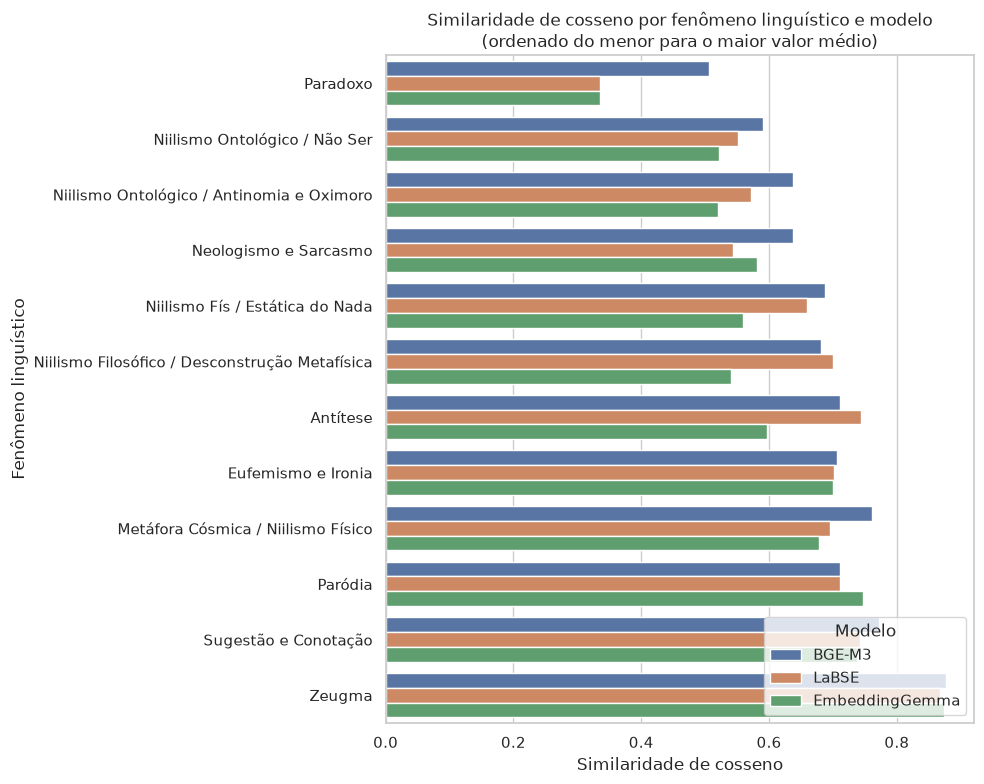

In [3]:
df_long = df.melt(
    id_vars=["id", "fenomeno_linguistico"],
    value_vars=SIM_COLS,
    var_name="modelo_col",
    value_name="similaridade",
)
df_long["modelo"] = df_long["modelo_col"].map(MODEL_LABELS)

ordem_fenomenos = (
    df_long.groupby("fenomeno_linguistico")["similaridade"]
    .mean()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=df_long,
    y="fenomeno_linguistico",
    x="similaridade",
    hue="modelo",
    order=ordem_fenomenos,
    ax=ax,
)
ax.set_xlabel("Similaridade de cosseno")
ax.set_ylabel("Fenômeno linguístico")
ax.set_title(
    "Similaridade de cosseno por fenômeno linguístico e modelo\n"
    "(ordenado do menor para o maior valor médio)"
)
ax.legend(title="Modelo", loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "similaridade_por_fenomeno.png", dpi=150, bbox_inches="tight")
plt.show()

Boxplot comparando a distribuição de similaridade dos três modelos lado a lado (com
os pontos individuais sobrepostos, já que temos poucos pares e vale ver cada um).
Isso mostra se algum modelo é sistematicamente mais "generoso" (similaridades mais
altas) ou mais disperso que os outros.

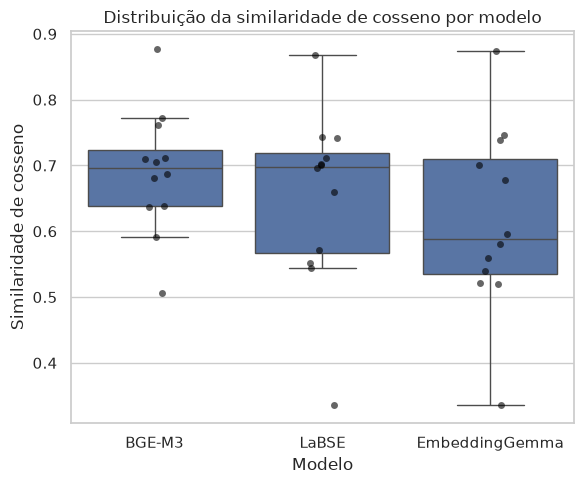

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df_long, x="modelo", y="similaridade", ax=ax, showfliers=False)
sns.stripplot(data=df_long, x="modelo", y="similaridade", color="black", alpha=0.6, ax=ax)
ax.set_xlabel("Modelo")
ax.set_ylabel("Similaridade de cosseno")
ax.set_title("Distribuição da similaridade de cosseno por modelo")
plt.tight_layout()
plt.show()

Scatter plot comparando BGE-M3 (eixo X) e LaBSE (eixo Y) par a par, com uma linha de
referência y=x: pontos sobre a linha indicam que os dois modelos concordam sobre
aquele par; pontos afastados da linha indicam divergência — um modelo "vê" o par como
muito mais próximo semanticamente do que o outro.

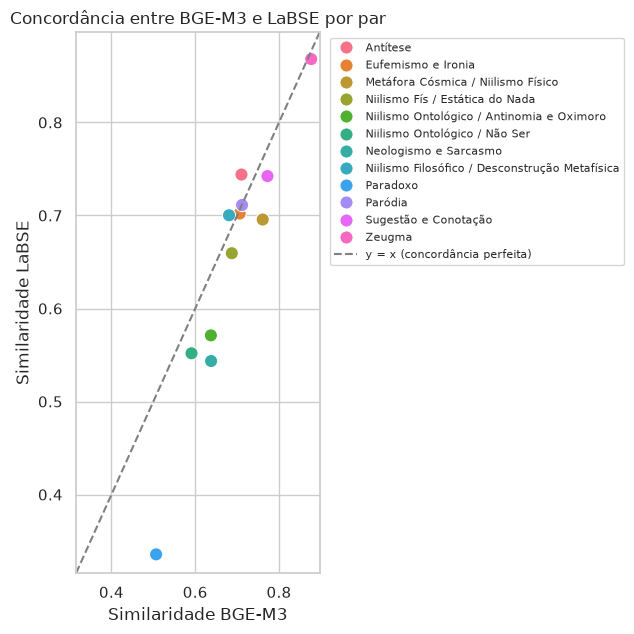

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
sns.scatterplot(
    data=df,
    x="similaridade_bge_m3",
    y="similaridade_labse",
    hue="fenomeno_linguistico",
    ax=ax,
    s=90,
)

lo = min(df["similaridade_bge_m3"].min(), df["similaridade_labse"].min()) - 0.02
hi = max(df["similaridade_bge_m3"].max(), df["similaridade_labse"].max()) + 0.02
ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray", label="y = x (concordância perfeita)")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Similaridade BGE-M3")
ax.set_ylabel("Similaridade LaBSE")
ax.set_title("Concordância entre BGE-M3 e LaBSE por par")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Heatmap fenômeno_linguistico × modelo, com a cor representando o valor de
similaridade — uma forma compacta de ver os três modelos e todos os fenômenos de uma
vez só, mantendo a mesma ordenação (menor → maior média) do gráfico de barras.

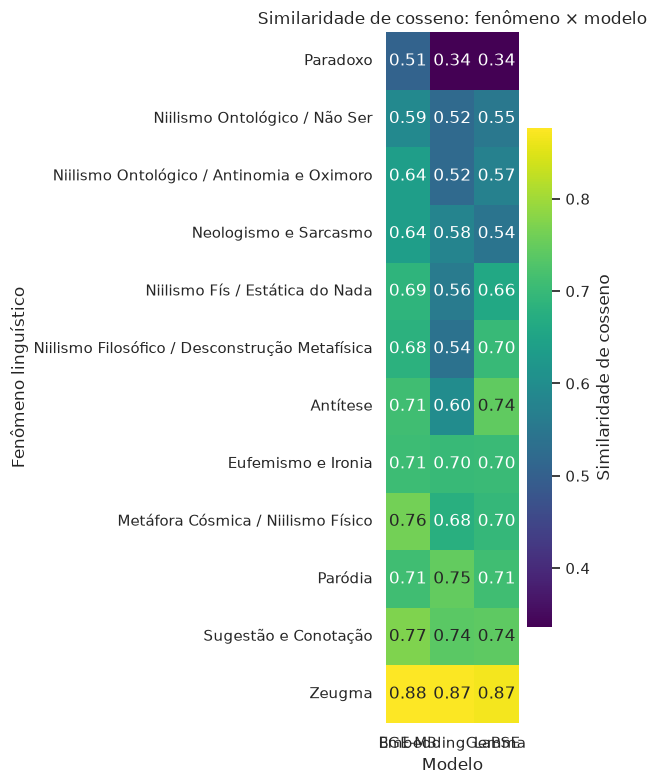

In [6]:
pivot = (
    df.pivot_table(index="fenomeno_linguistico", values=SIM_COLS, aggfunc="mean")
    .rename(columns=MODEL_LABELS)
    .reindex(ordem_fenomenos)
)

fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(
    pivot, annot=True, fmt=".2f", cmap="viridis", ax=ax,
    cbar_kws={"label": "Similaridade de cosseno"},
)
ax.set_xlabel("Modelo")
ax.set_ylabel("Fenômeno linguístico")
ax.set_title("Similaridade de cosseno: fenômeno × modelo")
plt.tight_layout()
plt.show()

## 3. Redução de dimensionalidade (PCA e UMAP)

O CSV da Fase 1 só nos dá o *escalar* de similaridade por par — para "ver" a geometria
do espaço de embeddings, geramos os vetores de todos os textos (originais e
simplificados) e projetamos em 2D com PCA e UMAP. Reutilizamos diretamente as classes
de `src/embeddings/models.py` (mesma interface `encode()` usada no pipeline da Fase
1), em vez de reimplementar o carregamento dos modelos aqui.

Cada par (original, simplificado) é conectado por uma linha no gráfico: linhas curtas
indicam que os dois textos do par caíram perto um do outro na projeção 2D; linhas
longas indicam divergência espacial — a mesma ideia de "estresse semântico", mas vista
geometricamente em vez de como um número só.

**Nota sobre UMAP com poucos pontos:** com apenas 24 vetores (12 pares × 2 textos), o
`n_neighbors` do UMAP foi reduzido para um valor pequeno (5) para caber no tamanho da
amostra; mesmo assim, a projeção com tão poucos pontos é instável e deve ser lida como
ilustrativa, não como uma representação fiel da estrutura do espaço de alta dimensão.

Instancia os três modelos (via `src/embeddings/models.py`) e monta um dataframe
"longo" com uma linha por texto (original e simplificado, para cada par), para então
gerar os embeddings de todos os textos com cada modelo.

In [7]:
MODELOS_REDUCAO = {
    "BGE-M3": BGEM3Model(),
    "LaBSE": LaBSEModel(),
    "EmbeddingGemma": EmbeddingGemmaModel(),
}

textos_long = []
for _, row in df.iterrows():
    textos_long.append({
        "id": row["id"],
        "fenomeno_linguistico": row["fenomeno_linguistico"],
        "tipo": "original",
        "texto": row["texto_original"],
    })
    textos_long.append({
        "id": row["id"],
        "fenomeno_linguistico": row["fenomeno_linguistico"],
        "tipo": "simplificado",
        "texto": row["texto_simplificado"],
    })
df_textos_long = pd.DataFrame(textos_long)

embeddings_por_modelo = {}
for nome_modelo, modelo in MODELOS_REDUCAO.items():
    print(f"Gerando embeddings com {nome_modelo}...")
    vetores = np.stack([modelo.encode(t) for t in df_textos_long["texto"]])
    embeddings_por_modelo[nome_modelo] = vetores
    print(f"  shape: {vetores.shape}")

Gerando embeddings com BGE-M3...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  shape: (24, 1024)
Gerando embeddings com LaBSE...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  shape: (24, 768)
Gerando embeddings com EmbeddingGemma...


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

  shape: (24, 768)


Define uma função de redução para 2D (PCA ou UMAP) e uma função de plot que desenha,
para cada par, uma linha conectando o ponto do texto original ao ponto do texto
simplificado, colorida por `fenomeno_linguistico`.

In [8]:
from matplotlib.lines import Line2D

# Paleta e marcadores fixados uma vez, com base no conjunto completo de fenômenos, para
# que a cor de cada fenômeno seja a mesma em todos os subplots (BGE-M3/LaBSE/EmbeddingGemma)
# e entre as figuras de PCA e UMAP.
FENOMENOS_ORDENADOS = sorted(df_textos_long["fenomeno_linguistico"].unique())
PALETA_FENOMENO = dict(zip(FENOMENOS_ORDENADOS, sns.color_palette("tab20", len(FENOMENOS_ORDENADOS))))
MARCADORES_TIPO = {"original": "o", "simplificado": "X"}


def reduzir_2d(vetores, metodo="pca", random_state=42):
    if metodo == "pca":
        reducer = PCA(n_components=2, random_state=random_state)
    elif metodo == "umap":
        n_neighbors = min(5, len(vetores) - 1)
        reducer = umap.UMAP(
            n_components=2, random_state=random_state,
            n_neighbors=n_neighbors, min_dist=0.3,
        )
    else:
        raise ValueError(metodo)
    return reducer.fit_transform(vetores)


def plot_pares_2d(coords, df_long, titulo, ax):
    df_plot = df_long.copy()
    df_plot["x"] = coords[:, 0]
    df_plot["y"] = coords[:, 1]

    for _, grupo in df_plot.groupby("id"):
        grupo = grupo.set_index("tipo")
        cor = PALETA_FENOMENO[grupo["fenomeno_linguistico"].iloc[0]]
        ax.plot(
            [grupo.loc["original", "x"], grupo.loc["simplificado", "x"]],
            [grupo.loc["original", "y"], grupo.loc["simplificado", "y"]],
            color=cor, alpha=0.6, linewidth=1.5, zorder=1,
        )

    sns.scatterplot(
        data=df_plot, x="x", y="y", hue="fenomeno_linguistico", style="tipo",
        palette=PALETA_FENOMENO, markers=MARCADORES_TIPO, s=80, ax=ax, zorder=2, legend=False,
    )
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")


def legenda_figura_pares(fig):
    # Legenda construída manualmente (cor = fenômeno, marcador = tipo do texto), já que
    # os subplots individuais têm legend=False para não repetir a mesma legenda 3x.
    handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=7, color=cor, label=fenomeno)
        for fenomeno, cor in PALETA_FENOMENO.items()
    ] + [
        Line2D([0], [0], marker=marcador, linestyle="", markersize=7, color="black", label=tipo)
        for tipo, marcador in MARCADORES_TIPO.items()
    ]
    fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.9), loc="upper left", fontsize=8)

Aplica PCA aos três modelos e plota os três lado a lado em subplots — cada par
conectado por uma linha, permitindo comparar visualmente o quanto cada modelo
"separa" original e simplificado no espaço reduzido.

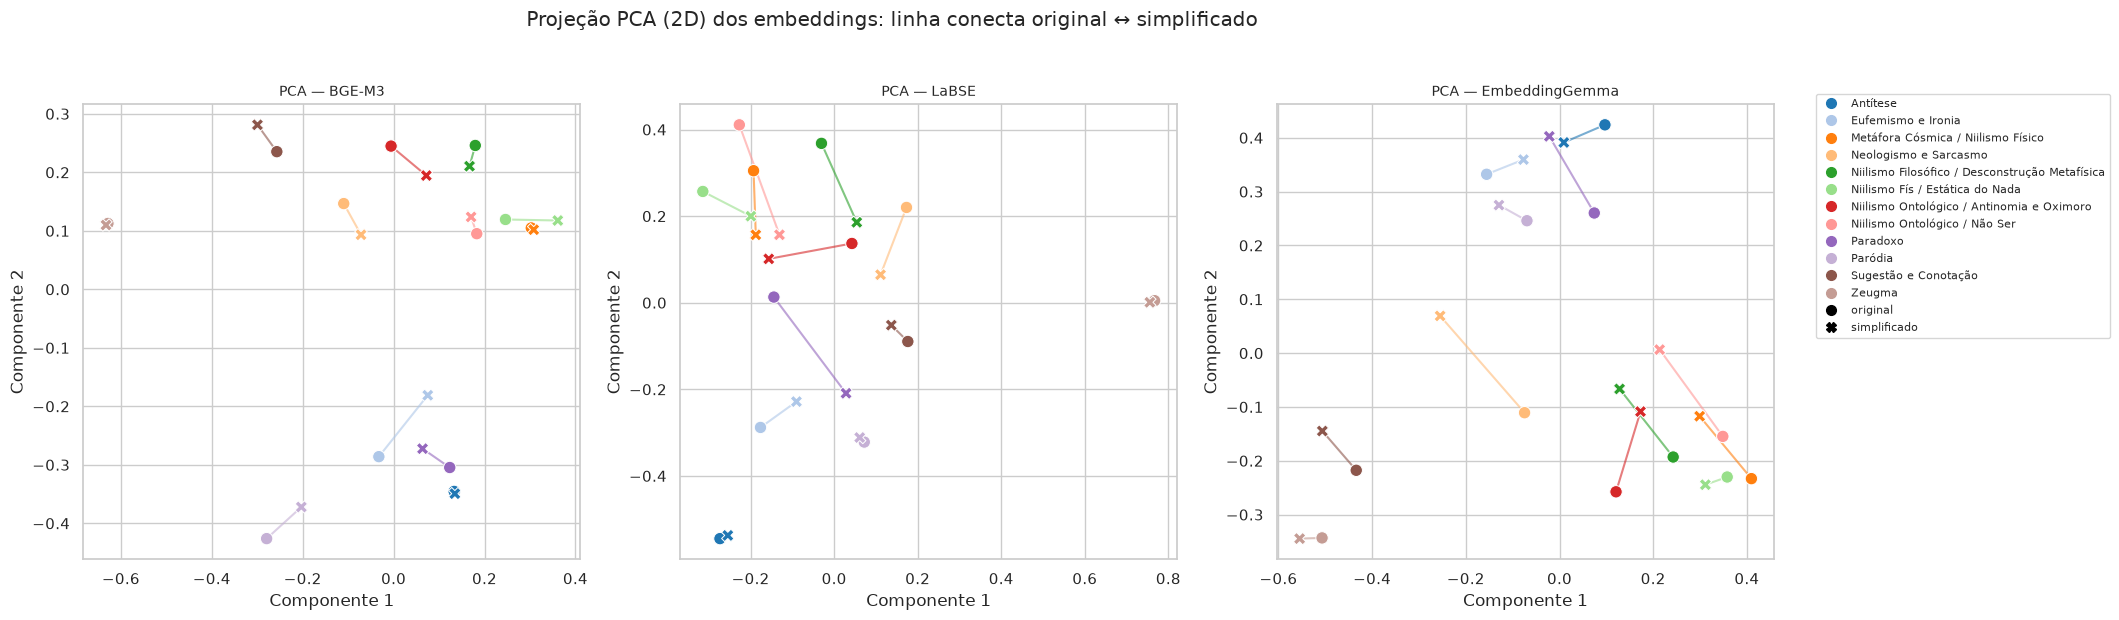

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (nome_modelo, vetores) in zip(axes, embeddings_por_modelo.items()):
    coords_pca = reduzir_2d(vetores, metodo="pca")
    plot_pares_2d(coords_pca, df_textos_long, f"PCA — {nome_modelo}", ax)

legenda_figura_pares(fig)
fig.suptitle(
    "Projeção PCA (2D) dos embeddings: linha conecta original ↔ simplificado",
    y=1.03,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "reducao_dimensionalidade_pca.png", dpi=150, bbox_inches="tight")
plt.show()

Repete a mesma análise com UMAP, que (diferente do PCA linear) pode capturar
estrutura não linear do espaço de embeddings — útil para checar se a separação
original/simplificado observada no PCA se mantém com uma técnica diferente.

/home/larissa/Documentos/semantic-stress-lab/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/larissa/Documentos/semantic-stress-lab/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/larissa/Documentos/semantic-stress-lab/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


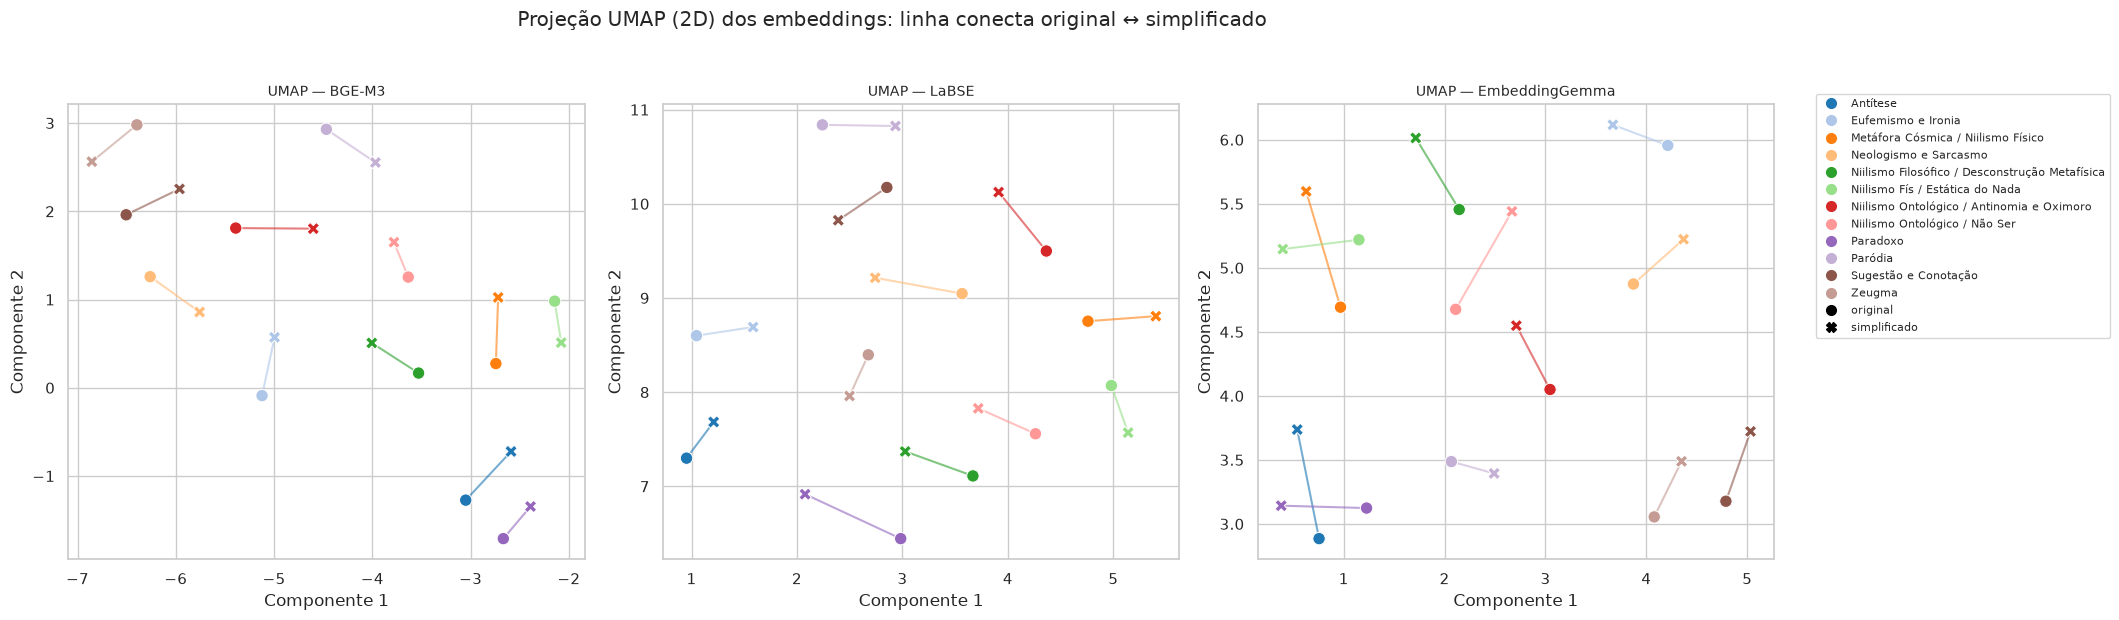

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (nome_modelo, vetores) in zip(axes, embeddings_por_modelo.items()):
    coords_umap = reduzir_2d(vetores, metodo="umap")
    plot_pares_2d(coords_umap, df_textos_long, f"UMAP — {nome_modelo}", ax)

legenda_figura_pares(fig)
fig.suptitle(
    "Projeção UMAP (2D) dos embeddings: linha conecta original ↔ simplificado",
    y=1.03,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "reducao_dimensionalidade_umap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Análise de outliers e casos extremos

Aqui saímos dos agregados e olhamos para pares específicos: onde os três modelos mais
discordam entre si, quais pares têm o "estresse semântico" mais forte (menor
similaridade média) e quais têm a maior concordância semântica (maior similaridade
média). Para cada caso, imprimimos o texto original e simplificado completos, para
leitura qualitativa — os números só fazem sentido lidos ao lado do texto.

Calcula, por par, a média, o máximo e o mínimo de similaridade entre os três modelos,
e a divergência entre eles (máximo − mínimo). Seleciona os 3 pares com maior
divergência, os 3 com menor similaridade média e os 3 com maior similaridade média.

In [11]:
df["sim_media"] = df[SIM_COLS].mean(axis=1)
df["sim_max"] = df[SIM_COLS].max(axis=1)
df["sim_min"] = df[SIM_COLS].min(axis=1)
df["divergencia_entre_modelos"] = df["sim_max"] - df["sim_min"]

top_divergentes = df.sort_values("divergencia_entre_modelos", ascending=False).head(3)
top_baixa_similaridade = df.sort_values("sim_media", ascending=True).head(3)
top_alta_similaridade = df.sort_values("sim_media", ascending=False).head(3)

top_divergentes[["id", "fenomeno_linguistico", "divergencia_entre_modelos"] + SIM_COLS]

,id,fenomeno_linguistico,divergencia_entre_modelos,similaridade_bge_m3,similaridade_labse,similaridade_embeddinggemma
8,vieira_002,Paradoxo,0.170924,0.506662,0.335738,0.335742
7,anjos_005,Niilismo Filosófico / Desconstrução Metafísica,0.160127,0.680633,0.700229,0.540102
0,vieira_001,Antítese,0.147830,0.710297,0.743994,0.596163


Função utilitária para imprimir, para um subconjunto de pares, o id, o fenômeno, as
três similaridades e os textos completos (original e simplificado) — usada para os
três casos extremos identificados acima.

In [12]:
def imprimir_casos(subset, titulo):
    print(f"\n{'=' * 80}\n{titulo}\n{'=' * 80}")
    for _, row in subset.iterrows():
        print(f"\n--- {row['id']} ({row['fenomeno_linguistico']}) ---")
        print(
            f"Similaridades: BGE-M3={row['similaridade_bge_m3']:.4f} | "
            f"LaBSE={row['similaridade_labse']:.4f} | "
            f"EmbeddingGemma={row['similaridade_embeddinggemma']:.4f}"
        )
        print(f"Texto original:\n  {row['texto_original']}")
        print(f"Texto simplificado:\n  {row['texto_simplificado']}")


imprimir_casos(top_divergentes, "3 PARES COM MAIOR DIVERGÊNCIA ENTRE MODELOS")
imprimir_casos(top_baixa_similaridade, "3 PARES COM MENOR SIMILARIDADE MÉDIA (mais 'estresse semântico')")
imprimir_casos(top_alta_similaridade, "3 PARES COM MAIOR SIMILARIDADE MÉDIA")


3 PARES COM MAIOR DIVERGÊNCIA ENTRE MODELOS

--- vieira_002 (Paradoxo) ---
Similaridades: BGE-M3=0.5067 | LaBSE=0.3357 | EmbeddingGemma=0.3357
Texto original:
  O semear não é assim... É uma arte sem arte, caia onde cair
Texto simplificado:
  A pregação do Evangelho não deve seguir regras rígidas e artificiais. Ela deve ser feita de forma simples e natural, espalhando a palavra de Deus para todas as pessoas, sem distinção.

--- anjos_005 (Niilismo Filosófico / Desconstrução Metafísica) ---
Similaridades: BGE-M3=0.6806 | LaBSE=0.7002 | EmbeddingGemma=0.5401
Texto original:
  Para que nesta vida o espírito esfalfaste / Em vãs meditações, homem meditabundo?! – / Escalpelaste todo o cadáver do mundo / E, por fim, nada achaste... e, por fim, nada achaste!...
Texto simplificado:
  Por qual motivo você cansou a sua mente nesta vida fazendo reflexões inúteis? Você analisou detalhadamente toda a realidade do mundo e, no fim, descobriu que não existe nenhum sentido ou verdade absoluta.

--- vie

## 5. Correlação com tamanho do texto (confounder)

Uma explicação alternativa (não literária) para baixa similaridade seria simplesmente
o quanto o texto muda de tamanho na "tradução" intralingual — textos simplificados
tendem a ser mais longos (parafraseiam o fenômeno retórico) e, em geral, embeddings
podem penalizar diferenças grandes de tamanho independente do conteúdo. Testamos essa
hipótese de confounding calculando a correlação de Pearson entre a diferença de
tamanho e a similaridade de cosseno.

**Aviso:** com n=12, qualquer correlação aqui é uma estimativa muito ruidosa — o
intervalo de confiança é largo e um único par pode mudar o resultado. Trate como
hipótese a investigar com mais dados, não como conclusão.

Calcula a diferença de tamanho (em caracteres, simplificado − original) para cada par,
e a correlação de Pearson (com p-valor) entre essa diferença e a similaridade de
cosseno, separadamente para cada um dos três modelos.

In [13]:
df["diff_tamanho"] = df["texto_simplificado"].str.len() - df["texto_original"].str.len()

correlacoes = {}
for col in SIM_COLS:
    r, p = pearsonr(df["diff_tamanho"], df[col])
    correlacoes[MODEL_LABELS[col]] = {"r_pearson": r, "p_valor": p}

df_correlacoes = pd.DataFrame(correlacoes).T
df_correlacoes

,r_pearson,p_valor
BGE-M3,0.039813,0.902230
LaBSE,-0.086213,0.789923
EmbeddingGemma,-0.093416,0.772762


Scatter plot da diferença de tamanho (eixo X) contra a similaridade (eixo Y), com
linha de tendência, um subplot por modelo — para visualizar a relação (ou ausência
dela) por trás dos números de correlação acima.

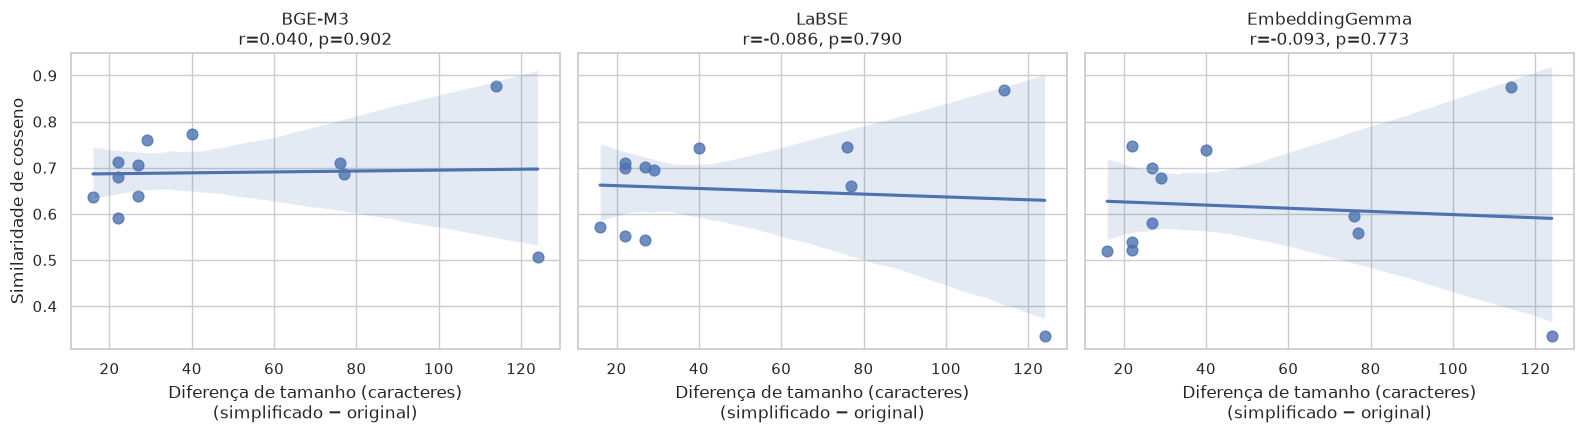

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, col in zip(axes, SIM_COLS):
    sns.regplot(data=df, x="diff_tamanho", y=col, ax=ax, scatter_kws={"s": 60})
    r = correlacoes[MODEL_LABELS[col]]["r_pearson"]
    p = correlacoes[MODEL_LABELS[col]]["p_valor"]
    ax.set_title(f"{MODEL_LABELS[col]}\nr={r:.3f}, p={p:.3f}")
    ax.set_xlabel("Diferença de tamanho (caracteres)\n(simplificado − original)")
    ax.set_ylabel("Similaridade de cosseno" if col == SIM_COLS[0] else "")
plt.tight_layout()
plt.show()

## 6. Estatísticas descritivas por categoria-mãe

Para ganhar poder estatístico (12 fenômenos quase todos com n=1 cada), agrupamos os
fenômenos linguísticos do dataset em categorias-mãe mais amplas.

**Este agrupamento é uma proposta minha para fins exploratórios, não uma
classificação linguística estabelecida ou definitiva** — outra pessoa lendo os mesmos
12 fenômenos poderia razoavelmente categorizá-los de forma diferente. A lógica usada:

- **Estrutural/Sintática** — o fenômeno atua na construção/organização da frase.
  Neste dataset: *Zeugma*.
- **Lógico-pragmática** — o fenômeno constrói uma relação de oposição, negação ou
  contradição conceitual (antítese, paradoxo, antinomia, oxímoro, niilismo enquanto
  postura ontológica/filosófica). Neste dataset: *Antítese*, *Paradoxo*, *Niilismo
  Ontológico / Antinomia e Oxímoro*, *Niilismo Fís / Estática do Nada*, *Niilismo
  Ontológico / Não Ser*, *Niilismo Filosófico / Desconstrução Metafísica*.
- **Lexical/Retórica** — o fenômeno é primariamente uma escolha lexical ou de
  registro (metáfora, eufemismo, ironia, neologismo, paródia, conotação). Neste
  dataset: *Eufemismo e Ironia*, *Metáfora Cósmica / Niilismo Físico*, *Neologismo e
  Sarcasmo*, *Paródia*, *Sugestão e Conotação*.

Como a categoria "Estrutural/Sintática" tem apenas 1 observação (Zeugma) neste
dataset, ela é reportada apenas de forma descritiva — está excluída do teste de
hipótese da próxima célula, que exige pelo menos 2 observações por grupo.

Aplica o mapeamento fenômeno → categoria-mãe definido acima e confere quantas
observações caem em cada categoria.

In [15]:
CATEGORIA_MAE = {
    "Zeugma": "Estrutural/Sintática",
    "Antítese": "Lógico-pragmática",
    "Paradoxo": "Lógico-pragmática",
    "Niilismo Ontológico / Antinomia e Oximoro": "Lógico-pragmática",
    "Niilismo Fís / Estática do Nada": "Lógico-pragmática",
    "Niilismo Ontológico / Não Ser": "Lógico-pragmática",
    "Niilismo Filosófico / Desconstrução Metafísica": "Lógico-pragmática",
    "Eufemismo e Ironia": "Lexical/Retórica",
    "Metáfora Cósmica / Niilismo Físico": "Lexical/Retórica",
    "Neologismo e Sarcasmo": "Lexical/Retórica",
    "Paródia": "Lexical/Retórica",
    "Sugestão e Conotação": "Lexical/Retórica",
}

df["categoria_mae"] = df["fenomeno_linguistico"].map(CATEGORIA_MAE)
assert df["categoria_mae"].notna().all(), "há fenômeno(s) fora do mapeamento acima"

df["categoria_mae"].value_counts()

categoria_mae
Lógico-pragmática       6
Lexical/Retórica        5
Estrutural/Sintática    1
Name: count, dtype: int64

Média e desvio padrão de similaridade por categoria-mãe, para cada um dos três
modelos.

In [16]:
stats_categoria = (
    df.groupby("categoria_mae")[SIM_COLS]
    .agg(["mean", "std"])
    .rename(columns=MODEL_LABELS, level=0)
)
stats_categoria

BGE-M3               LaBSE           EmbeddingGemma  \
                          mean       std      mean       std           mean   
categoria_mae                                                                 
Estrutural/Sintática  0.876851       NaN  0.868123       NaN       0.874227   
Lexical/Retórica      0.717834  0.053425  0.678979  0.077802       0.688658   
Lógico-pragmática     0.635549  0.076006  0.593733  0.146328       0.511963   

                                
                           std  
categoria_mae                   
Estrutural/Sintática       NaN  
Lexical/Retórica      0.066573  
Lógico-pragmática     0.090857

Compara estatisticamente as duas categorias com pelo menos 2 observações
(Lógico-pragmática vs. Lexical/Retórica). Com amostras tão pequenas (n=5 e n=6), um
teste t assume normalidade que não dá para verificar — por isso usamos o teste de
Mann-Whitney U (não paramétrico) como escolha mais conservadora, mas **o resultado
deve ser lido como indicativo, não conclusivo**: com n < 10 por grupo, o poder
estatístico é muito baixo e um único par diferente poderia mudar o resultado.

In [17]:
contagens = df["categoria_mae"].value_counts()
categorias_testaveis = contagens[contagens >= 2].index.tolist()
print(f"Categorias com n>=2 observações: {categorias_testaveis}")
print(f"(Estrutural/Sintática tem n={contagens.get('Estrutural/Sintática', 0)} — excluída do teste)")

resultados_teste = []
if len(categorias_testaveis) >= 2:
    c1, c2 = categorias_testaveis[0], categorias_testaveis[1]
    g1 = df[df["categoria_mae"] == c1]
    g2 = df[df["categoria_mae"] == c2]
    n1, n2 = len(g1), len(g2)
    usar_t = n1 >= 8 and n2 >= 8  # amostra pequena demais para assumir normalidade abaixo disso
    for col in SIM_COLS:
        if usar_t:
            estat, p = ttest_ind(g1[col], g2[col])
            teste = "t de Student"
        else:
            estat, p = mannwhitneyu(g1[col], g2[col], alternative="two-sided")
            teste = "Mann-Whitney U"
        resultados_teste.append({
            "modelo": MODEL_LABELS[col],
            "comparação": f"{c1} (n={n1}) vs. {c2} (n={n2})",
            "teste": teste,
            "estatística": estat,
            "p_valor": p,
        })

df_testes = pd.DataFrame(resultados_teste)
df_testes

Categorias com n>=2 observações: ['Lógico-pragmática', 'Lexical/Retórica']
(Estrutural/Sintática tem n=1 — excluída do teste)


,modelo,comparação,teste,estatística,p_valor
0,BGE-M3,Lógico-pragmática (n=6) vs. Lexical/Retórica (...,Mann-Whitney U,4.0,0.051948
1,LaBSE,Lógico-pragmática (n=6) vs. Lexical/Retórica (...,Mann-Whitney U,10.0,0.428571
2,EmbeddingGemma,Lógico-pragmática (n=6) vs. Lexical/Retórica (...,Mann-Whitney U,1.0,0.008658


## 7. Dependência de contexto prévio (deixis/anáfora)

Pergunta que motivou esta seção: será que a baixa similaridade encontrada nos fenômenos lógico-pragmáticos (Seção 6) reflete o fenômeno retórico em si, ou o fato de que alguns fragmentos pressupõem um contexto que não está no recorte extraído (um conectivo como "mas ainda" remetendo a algo dito antes, um pronome deítico sem antecedente, uma apóstrofe a um interlocutor não identificado)? Se um trecho é difícil de entender mesmo para um leitor humano fora de contexto, é esperado que um modelo de embedding também tenha dificuldade — e essa dificuldade não teria relação nenhuma com o fenômeno literário sendo testado. Isso seria um confounder sério para a hipótese central do projeto.

Para investigar, classifiquei manualmente cada um dos 12 pares quanto à presença de elementos que dependem de contexto anterior para fazer sentido pleno: conectivo presuposicional sem antecedente no trecho (ex.: "mas ainda"), dêixis não resolvível dentro do fragmento (ex.: "aonde eu fui"), apóstrofe a um interlocutor não identificado no próprio trecho, ou marcador explícito de elisão ("(...)").

**Esta classificação é minha, feita para fins exploratórios — não é uma anotação linguística formal, e um leitor com outro critério poderia discordar de alguns casos específicos** (em particular `anjos_005`, que também é uma apóstrofe, mas a um interlocutor genérico — "homem meditabundo" — e não a alguém específico não identificado, por isso ficou classificado como autocontido).

Aplica a classificação par a par, com o motivo registrado para cada caso (para que a decisão fique auditável, não seja uma caixa-preta).

In [18]:
CONTEXTO_PREVIO = {
    "vieira_001": (True, "Conectivo 'Mas ainda' pressupõe fala anterior; 'a seara aonde eu fui, e para onde venho' é dêixis não resolvível no trecho."),
    "assis_001": (False, "Reflexão autocontida, sem referência externa necessária."),
    "anjos_001": (False, "Imagem sensorial em primeira pessoa, autocontida."),
    "anjos_002": (True, "Começa com 'É a dor de...' — sujeito elíptico que remete a algo fora do trecho."),
    "anjos_003": (True, "Apóstrofe ('Agregado infeliz... filho...') sem indicar quem é o interlocutor dentro do trecho."),
    "anjos_004": (True, "Apóstrofe a 'tu, feto esquecido' — interlocutor não identificado no trecho."),
    "andrade_001": (True, "Contém elisão explícita '(...)' sinalizando trecho suprimido do original."),
    "anjos_005": (False, "Apóstrofe a um interlocutor genérico ('homem meditabundo'), não a alguém específico não identificado."),
    "vieira_002": (True, "'não é assim' é anafórico a algo dito antes, não recuperável dentro do trecho."),
    "andrade_002": (False, "É a frase de abertura do romance (ver campo 'notas' do dataset) — não pressupõe nada anterior."),
    "azevedo_001": (False, "Personagem apresentado dentro da própria frase, autocontido."),
    "assis_002": (False, "Personagem apresentado dentro da própria frase, autocontido."),
}

df["precisa_contexto_previo"] = df["id"].map(lambda i: CONTEXTO_PREVIO[i][0])
df["motivo_contexto"] = df["id"].map(lambda i: CONTEXTO_PREVIO[i][1])

df[["id", "fenomeno_linguistico", "precisa_contexto_previo", "motivo_contexto"]]

,id,fenomeno_linguistico,precisa_contexto_previo,motivo_contexto
0,vieira_001,Antítese,True,Conectivo 'Mas ainda' pressupõe fala anterior;...
1,assis_001,Eufemismo e Ironia,False,"Reflexão autocontida, sem referência externa n..."
2,anjos_001,Metáfora Cósmica / Niilismo Físico,False,"Imagem sensorial em primeira pessoa, autocontida."
3,anjos_002,Niilismo Fís / Estática do Nada,True,Começa com 'É a dor de...' — sujeito elíptico ...
4,anjos_003,Niilismo Ontológico / Antinomia e Oximoro,True,Apóstrofe ('Agregado infeliz... filho...') sem...
5,anjos_004,Niilismo Ontológico / Não Ser,True,"Apóstrofe a 'tu, feto esquecido' — interlocuto..."
6,andrade_001,Neologismo e Sarcasmo,True,Contém elisão explícita '(...)' sinalizando tr...
7,anjos_005,Niilismo Filosófico / Desconstrução Metafísica,False,Apóstrofe a um interlocutor genérico ('homem m...
8,vieira_002,Paradoxo,True,"'não é assim' é anafórico a algo dito antes, n..."
9,andrade_002,Paródia,False,É a frase de abertura do romance (ver campo 'n...


Antes de comparar as similaridades, vale checar o quanto essa classificação se sobrepõe às categorias-mãe da Seção 6 — se "precisa de contexto prévio" e "é lógico-pragmático" forem quase a mesma coisa neste dataset, os dois efeitos ficam confundidos e não dá para separar um do outro com os dados atuais.

In [19]:
pd.crosstab(df["categoria_mae"], df["precisa_contexto_previo"])

precisa_contexto_previo,False,True
categoria_mae,,
Estrutural/Sintática,1,0
Lexical/Retórica,4,1
Lógico-pragmática,1,5


Compara a similaridade média (`sim_media`) e a divergência entre modelos entre os pares que precisam de contexto prévio e os que são autocontidos, com teste de Mann-Whitney (mesma escolha da Seção 6, pelo mesmo motivo: amostra pequena demais para assumir normalidade). Com 6 pares em cada grupo, é a comparação mais balanceada do notebook — mas ainda pequena demais para conclusões fortes.

In [20]:
g_dependente = df[df["precisa_contexto_previo"]]
g_autocontido = df[~df["precisa_contexto_previo"]]

print(f"Precisa de contexto prévio: n={len(g_dependente)}  |  Autocontido: n={len(g_autocontido)}")

resultados_contexto = []
for metrica in ["sim_media", "divergencia_entre_modelos"]:
    estat, p = mannwhitneyu(g_dependente[metrica], g_autocontido[metrica], alternative="two-sided")
    resultados_contexto.append({
        "métrica": metrica,
        "média (precisa contexto)": g_dependente[metrica].mean(),
        "média (autocontido)": g_autocontido[metrica].mean(),
        "estatística U": estat,
        "p_valor": p,
    })

df_resultados_contexto = pd.DataFrame(resultados_contexto)
df_resultados_contexto

Precisa de contexto prévio: n=6  |  Autocontido: n=6


,métrica,média (precisa contexto),média (autocontido),estatística U,p_valor
0,sim_media,0.571579,0.733645,1.0,0.004329
1,divergencia_entre_modelos,0.121505,0.054509,30.0,0.064935


Visualiza a mesma comparação: um boxplot com os pontos individuais para `sim_media` e outro para `divergencia_entre_modelos`, lado a lado, separados por grupo.

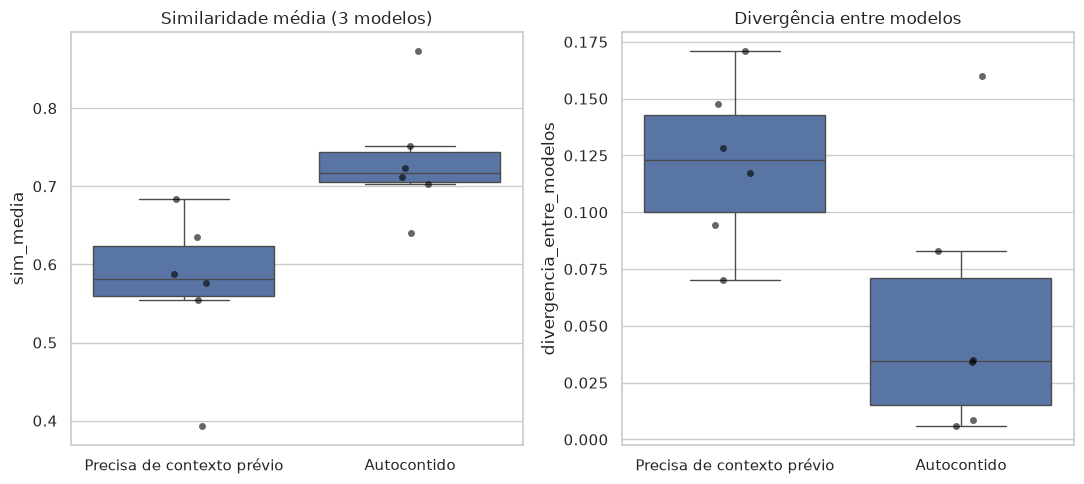

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

df_plot = df.copy()
df_plot["grupo_contexto"] = df_plot["precisa_contexto_previo"].map(
    {True: "Precisa de contexto prévio", False: "Autocontido"}
)

for ax, col, titulo in zip(
    axes,
    ["sim_media", "divergencia_entre_modelos"],
    ["Similaridade média (3 modelos)", "Divergência entre modelos"],
):
    sns.boxplot(data=df_plot, x="grupo_contexto", y=col, ax=ax, showfliers=False)
    sns.stripplot(data=df_plot, x="grupo_contexto", y=col, color="black", alpha=0.6, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

**Achado:** a diferença é grande e estatisticamente significativa para a similaridade média (0,73 vs. 0,57; Mann-Whitney p ≈ 0,004) — pares autocontidos têm similaridade bem mais alta que pares que dependem de contexto prévio. A divergência entre modelos também é maior no grupo dependente de contexto (0,12 vs. 0,05), mas o teste fica só marginalmente significativo (p ≈ 0,065) com esse n.

Mais revelador é o cruzamento com a categoria-mãe da Seção 6: **5 dos 6 pares "Lógico-pragmática" também foram classificados como dependentes de contexto prévio**, contra apenas 1 dos 5 "Lexical/Retórica" e 0 do único "Estrutural/Sintática". Ou seja, neste dataset de 12 pares, "ser lógico-pragmático" e "precisar de contexto prévio" estão quase perfeitamente confundidos — não dá para separar estatisticamente qual dos dois fatores está de fato reduzindo a similaridade. O achado da Seção 6 ("paradoxo e antítese derivam mais") pode ser, ao menos parcialmente, um artefato de esses mesmos textos também serem os que mais dependem de contexto que foi cortado do recorte, e não puramente do fenômeno retórico.

**Isso não invalida a análise, mas limita o que dá para concluir dela agora**: a comparação relativa entre texto original e simplificado dentro de cada par continua válida (os dois membros do par compartilham o mesmo déficit de contexto), mas comparar *entre* fenômenos/categorias fica menos confiável enquanto os dois fatores estiverem confundidos. Para separar os efeitos seria necessário expandir o dataset garantindo que cada categoria-mãe tenha exemplos autocontidos e dependentes de contexto em proporções parecidas — um critério concreto a mais para a expansão do dataset já listada nos "Próximos passos" da apresentação.

## 7.1. O confound de contexto persiste depois de corrigir pelo piso de controle?

A Seção 7 encontrou uma diferença grande entre pares que precisam de contexto prévio e pares autocontidos, mas usando similaridade de cosseno bruta — uma escala que já sabemos não ser diretamente comparável entre os três modelos (cada um tem seu próprio "piso de repouso" para uma paráfrase trivial; ver `results/phase1_embeddings/control_baseline_similarity.csv` e `phenomenon_zscore_vs_control.csv`, gerados no experimento de controle).

Pergunta desta seção: será que o confound de dependência de contexto continua igualmente forte quando a variável analisada é o **z-score de cada fenômeno em relação ao piso de controle** — ou seja, quantos desvios-padrão abaixo do que se espera de uma paráfrase trivial cada par está — em vez da similaridade bruta? Se o confound desaparecer ou enfraquecer bastante nessa escala corrigida, isso sugeriria que parte do efeito da Seção 7 era um artefato da escala bruta. Se persistir com força parecida, a ressalva da Seção 7 fica reforçada, não enfraquecida.

In [22]:
zscores = pd.read_csv(project_root / "results" / "phase1_embeddings" / "phenomenon_zscore_vs_control.csv")
Z_COLS = ["zscore_bge_m3", "zscore_labse", "zscore_embeddinggemma"]

# fenomeno_linguistico é 1:1 com id neste dataset (12 pares, 12 fenômenos distintos),
# então o merge por fenomeno_linguistico equivale a um merge por id.
assert df["fenomeno_linguistico"].nunique() == len(df), "fenomeno_linguistico não é 1:1 com id"

df = df.merge(zscores, on="fenomeno_linguistico", how="left")
df["z_media"] = df[Z_COLS].mean(axis=1)

df[["id", "fenomeno_linguistico", "precisa_contexto_previo"] + Z_COLS + ["z_media"]]

,id,fenomeno_linguistico,precisa_contexto_previo,zscore_bge_m3,zscore_labse,zscore_embeddinggemma,z_media
0,vieira_001,Antítese,True,-9.44,-9.95,-12.90,-10.763333
1,assis_001,Eufemismo e Ironia,False,-9.61,-11.82,-9.06,-10.163333
2,anjos_001,Metáfora Cósmica / Niilismo Físico,False,-7.44,-12.11,-9.88,-9.810000
3,anjos_002,Niilismo Fís / Estática do Nada,True,-10.35,-13.72,-14.27,-12.780000
4,anjos_003,Niilismo Ontológico / Antinomia e Oximoro,True,-12.33,-17.67,-15.70,-15.233333
5,anjos_004,Niilismo Ontológico / Não Ser,True,-14.15,-18.53,-15.67,-16.116667
6,andrade_001,Neologismo e Sarcasmo,True,-12.30,-18.90,-13.47,-14.890000
7,anjos_005,Niilismo Filosófico / Desconstrução Metafísica,False,-10.61,-11.90,-14.96,-12.490000
8,vieira_002,Paradoxo,True,-17.49,-28.18,-22.49,-22.720000
9,andrade_002,Paródia,False,-9.38,-11.41,-7.36,-9.383333


Roda o mesmo teste de Mann-Whitney da Seção 7 (dependente de contexto vs. autocontido), agora em três versões: uma por modelo (`zscore_bge_m3`, `zscore_labse`, `zscore_embeddinggemma`) e uma combinada (`z_media`, média dos três — o análogo direto do `sim_media` usado na Seção 7, para comparação mais justa com o p-valor original de 0,004).

In [23]:
g_dependente_z = df[df["precisa_contexto_previo"]]
g_autocontido_z = df[~df["precisa_contexto_previo"]]

resultados_zscore = []
for col in Z_COLS + ["z_media"]:
    estat, p = mannwhitneyu(g_dependente_z[col], g_autocontido_z[col], alternative="two-sided")
    resultados_zscore.append({
        "variável": col,
        "média (precisa contexto)": g_dependente_z[col].mean(),
        "média (autocontido)": g_autocontido_z[col].mean(),
        "estatística U": estat,
        "p_valor": p,
    })

df_resultados_zscore = pd.DataFrame(resultados_zscore)
df_resultados_zscore

,variável,média (precisa contexto),média (autocontido),estatística U,p_valor
0,zscore_bge_m3,-12.676667,-7.813333,3.0,0.015152
1,zscore_labse,-17.825000,-10.276667,5.0,0.041126
2,zscore_embeddinggemma,-15.750000,-8.595000,3.0,0.015152
3,z_media,-15.417222,-8.895000,1.0,0.004329


**Achado:** o confound **não desaparece nem enfraquece** ao corrigir pela escala de cada modelo — ele se mantém com força praticamente igual.

- Nos três modelos individualmente, o grupo "precisa de contexto prévio" tem z-score muito mais negativo que o autocontido, e a diferença continua estatisticamente significativa: BGE-M3 (-12,68 vs. -7,81; p ≈ 0,015), LaBSE (-17,83 vs. -10,28; p ≈ 0,041), EmbeddingGemma (-15,75 vs. -8,60; p ≈ 0,015).
- Na versão combinada (`z_media`, o análogo direto do `sim_media` da Seção 7), o resultado é quase idêntico ao original em similaridade bruta: -15,42 vs. -8,90, p ≈ 0,0043 — praticamente o mesmo p-valor de 0,004 obtido antes.

**Conclusão desta seção:** o confound de dependência de contexto **não era um artefato da escala bruta de similaridade** — ele sobrevive intacto depois de expressar cada fenômeno em relação ao piso de controle específico de cada modelo. Isso reforça, em vez de enfraquecer, a ressalva da Seção 7: com os dados atuais (n=12, 6 vs. 6), ainda não dá para separar estatisticamente "ser lógico-pragmático" de "depender de contexto prévio" — e agora sabemos que essa indistinguibilidade não é resolvida simplesmente medindo o efeito numa escala mais rigorosa. O próximo passo continua sendo o já apontado: expandir o dataset balanceando pares autocontidos e dependentes de contexto dentro de cada categoria-mãe.

## 8. Expansão para n=25 pares: a hierarquia de fenômenos se sustenta?

O achado 1 desta análise ("Paradoxo/lógico-pragmático é o fenômeno mais hostil aos
embeddings") vinha de uma única observação de Paradoxo (`vieira_002`) contra uma única
observação de Zeugma (`assis_002`) — n=1 em ambos os extremos. Depois de resolver
sobreposições e ambiguidades bibliográficas no dataset de anotação, adicionamos 13
pares novos (mais sonetos de Camões e Gregório de Matos, um trecho de Brás Cubas, dois
fragmentos de Ricardo Reis/Pessoa), elevando o dataset de 12 para 25 pares e dando a
Paradoxo, Antítese, Hipérbato e Zeugma mais de uma observação cada pela primeira vez.

Esta seção roda a Fase 1 completa nesse dataset expandido (mesmos três modelos, mesmo
piso de controle já estabelecido) e faz a pergunta central: a hierarquia "Paradoxo
pior, Zeugma melhor" sobrevive quando deixa de ser uma comparação n=1 vs. n=1?

In [24]:
SIM_V1_PATH = project_root / "results" / "phase1_embeddings" / "cosine_similarity_by_model_v1.csv"
df_v1 = pd.read_csv(SIM_V1_PATH)
df_v1["sim_media"] = df_v1[SIM_COLS].mean(axis=1)
df_v1["sim_max"] = df_v1[SIM_COLS].max(axis=1)
df_v1["sim_min"] = df_v1[SIM_COLS].min(axis=1)
df_v1["divergencia_entre_modelos"] = df_v1["sim_max"] - df_v1["sim_min"]

print(f"n={len(df_v1)} pares (era n=12 nas Seções 1-7)")
df_v1[["id", "autor", "fenomeno_linguistico"] + SIM_COLS].sort_values("id")

n=25 pares (era n=12 nas Seções 1-7)


,id,autor,fenomeno_linguistico,similaridade_bge_m3,similaridade_labse,similaridade_embeddinggemma
6,andrade_001,Mário de Andrade,Neologismo e Sarcasmo,0.637878,0.543537,0.580502
9,andrade_002,Mário de Andrade,Paródia,0.711774,0.711262,0.746364
2,anjos_001,Augusto dos Anjos,Metáfora Cósmica / Niilismo Físico,0.761039,0.695664,0.677980
3,anjos_002,Augusto dos Anjos,Niilismo Fís / Estática do Nada,0.687272,0.659424,0.558797
4,anjos_003,Augusto dos Anjos,Niilismo Ontológico / Antinomia e Oximoro,0.637321,0.571136,0.519966
5,anjos_004,Augusto dos Anjos,Niilismo Ontológico / Não Ser,0.591112,0.551879,0.521008
7,anjos_005,Augusto dos Anjos,Niilismo Filosófico / Desconstrução Metafísica,0.680633,0.700229,0.540102
1,assis_001,Machado de Assis,Eufemismo e Ironia,0.706042,0.702112,0.700273
11,assis_002,Machado de Assis,Zeugma,0.876851,0.868123,0.874227
14,assis_003,Machado de Assis,Ironia estrutural / Inversão conceitual,0.775635,0.622596,0.736547


Com n=25, quatro fenômenos deixam de ter n=1 e passam a ter desvio padrão calculável:
Paradoxo (4), Antítese (4), Hipérbato (3), Zeugma (2).

In [25]:
agg_v1 = (
    df_v1.groupby("fenomeno_linguistico")
    .agg(n=("id", "size"), **{f"{c}_media": (c, "mean") for c in SIM_COLS},
         **{f"{c}_dp": (c, "std") for c in SIM_COLS})
    .sort_values(f"{SIM_COLS[0]}_media")
)
multi_v1 = agg_v1[agg_v1["n"] >= 2]
multi_v1[["n"] + [f"{c}_media" for c in SIM_COLS] + [f"{c}_dp" for c in SIM_COLS]]

,n,similaridade_bge_m3_media,similaridade_labse_media,similaridade_embeddinggemma_media,similaridade_bge_m3_dp,similaridade_labse_dp,similaridade_embeddinggemma_dp
fenomeno_linguistico,,,,,,,
Hipérbato,3,0.767462,0.836497,0.747495,0.113629,0.122115,0.117864
Paradoxo,4,0.788794,0.751860,0.705580,0.194291,0.278396,0.250421
Antítese,4,0.807289,0.818245,0.751786,0.083940,0.103996,0.120277
Zeugma,2,0.884439,0.894442,0.863324,0.010730,0.037221,0.015419


O agregado acima já sugere algo estranho: o desvio padrão de Paradoxo (≈0,19–0,28) é
disparadamente o maior do dataset. Olhando par a par:

In [26]:
df_v1[df_v1["fenomeno_linguistico"] == "Paradoxo"][["id", "autor"] + SIM_COLS + ["sim_media"]]

,id,autor,similaridade_bge_m3,similaridade_labse,similaridade_embeddinggemma,sim_media
8,vieira_002,Padre Antônio Vieira,0.506662,0.335738,0.335742,0.392714
12,camoes_001,Luís de Camões,0.819130,0.887073,0.767448,0.824550
13,matos_001,Gregório de Matos,0.937360,0.863869,0.866709,0.889313
22,matos_006,Gregório de Matos,0.892026,0.920761,0.852421,0.888403


O gráfico abaixo (mesmo estilo das Seções 1-6, agora com barras de erro = desvio
padrão onde n>1) deixa visual o que a tabela mostra: Paradoxo deixou de ser a barra
mais baixa e virou a mais *larga* — a categoria com maior variância interna do
dataset inteiro, não a de menor similaridade média.

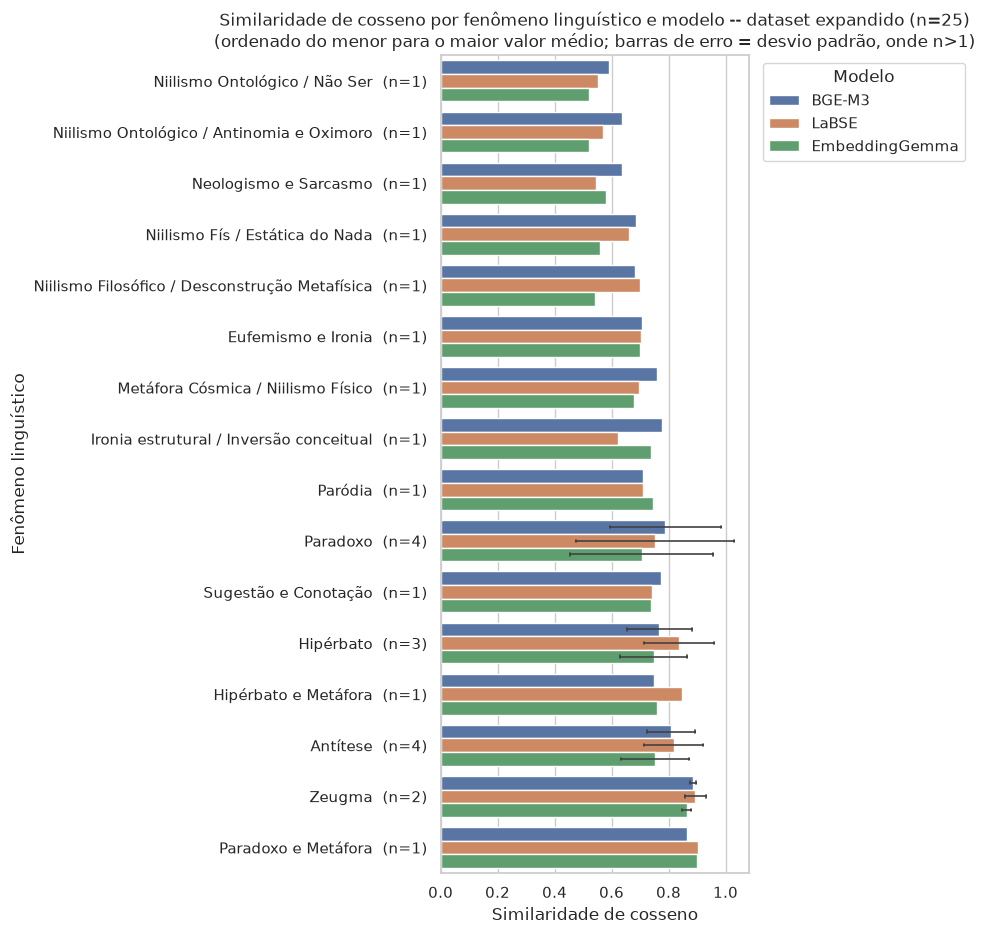

In [27]:
df_v1_long = df_v1.melt(
    id_vars=["id", "fenomeno_linguistico"], value_vars=SIM_COLS,
    var_name="modelo_col", value_name="similaridade",
)
df_v1_long["modelo"] = df_v1_long["modelo_col"].map(MODEL_LABELS)

n_por_fenomeno_v1 = df_v1.groupby("fenomeno_linguistico").size()
ordem_v1 = df_v1_long.groupby("fenomeno_linguistico")["similaridade"].mean().sort_values().index
labels_com_n_v1 = [f"{fen}  (n={n_por_fenomeno_v1[fen]})" for fen in ordem_v1]

fig, ax = plt.subplots(figsize=(10, 9.5))
sns.barplot(
    data=df_v1_long, y="fenomeno_linguistico", x="similaridade", hue="modelo",
    order=ordem_v1, errorbar="sd", capsize=0.15, err_kws={"linewidth": 1.2}, ax=ax,
)
ax.set_yticks(range(len(labels_com_n_v1)))
ax.set_yticklabels(labels_com_n_v1)
ax.set_xlabel("Similaridade de cosseno")
ax.set_ylabel("Fenômeno linguístico")
ax.set_title(
    "Similaridade de cosseno por fenômeno linguístico e modelo -- dataset expandido (n=25)\n"
    "(ordenado do menor para o maior valor médio; barras de erro = desvio padrão, onde n>1)"
)
ax.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "similarity_by_phenomenon_v1.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.1. O confound de dependência de contexto, agora com n=25

Os 13 pares novos foram classificados manualmente com os mesmos 4 critérios da Seção 7
(conectivo presuposicional sem antecedente, dêixis não resolvível, apóstrofe a
interlocutor não identificado, elisão explícita). O teste de Mann-Whitney da Seção 7
(similaridade bruta, dependente de contexto vs. autocontido) é refeito abaixo com a
amostra maior.

In [28]:
CONTEXTO_PREVIO_V1 = dict(CONTEXTO_PREVIO)  # reaproveita as 12 classificações da Seção 7
CONTEXTO_PREVIO_V1.update({
    "camoes_001": (False, "Soneto completo, autocontido: definições paradoxais + pergunta retórica final, sem referente externo."),
    "matos_001": (True, "Apóstrofe ('Sois Anjo...') a interlocutor referido só por epíteto, não identificado no verso isolado."),
    "assis_003": (False, "Sujeito ('A loucura, objeto dos meus estudos') definido dentro do próprio trecho."),
    "camoes_002": (True, "Dêixis não resolvível: 'Aquela...madrugada' remete a um evento específico não descrito no fragmento (só o 1º verso)."),
    "camoes_003": (True, "Apóstrofe ('Repousa lá no Céu...') a um 'tu' não identificado no dístico isolado."),
    "matos_002": (True, "Conectivo presuposicional 'Que' sem antecedente no trecho + apóstrofe a interlocutor não identificado (Cristo não é nomeado aqui)."),
    "matos_003": (False, "Soneto completo, autocontido: argumento filosófico fechado, sem 'tu' específico não identificado."),
    "matos_004": (False, "Mesmo texto de matos_003 (soneto completo) -- autocontido."),
    "matos_005": (False, "Mesmo texto de matos_003 (soneto completo) -- autocontido."),
    "matos_006": (False, "Mesmo texto de matos_003 (soneto completo) -- autocontido."),
    "pessoa_001": (False, "Apóstrofe, mas o interlocutor É nomeado no próprio trecho ('a ti, Cristo') -- mesmo padrão de anjos_005."),
    "assis_004": (False, "Argumento narrativo completo, contextualiza seus próprios referentes (Moisés, Pentateuco) no próprio trecho."),
    "pessoa_002": (False, "Imperativo a um 'tu' genérico (máxima moral), não um interlocutor específico não identificado -- mesmo padrão de anjos_005/pessoa_001."),
})

df_v1["precisa_contexto_previo"] = df_v1["id"].map(lambda i: CONTEXTO_PREVIO_V1[i][0])

g_dep_v1 = df_v1[df_v1["precisa_contexto_previo"]]
g_auto_v1 = df_v1[~df_v1["precisa_contexto_previo"]]
print(f"Precisa de contexto prévio: n={len(g_dep_v1)}  |  Autocontido: n={len(g_auto_v1)}")

resultados_v1 = []
for metrica in ["sim_media", "divergencia_entre_modelos"]:
    estat, p = mannwhitneyu(g_dep_v1[metrica], g_auto_v1[metrica], alternative="two-sided")
    resultados_v1.append({
        "métrica": metrica,
        "média (precisa contexto)": g_dep_v1[metrica].mean(),
        "média (autocontido)": g_auto_v1[metrica].mean(),
        "estatística U": estat,
        "p_valor": p,
    })
pd.DataFrame(resultados_v1)

Precisa de contexto prévio: n=10  |  Autocontido: n=15


,métrica,média (precisa contexto),média (autocontido),estatística U,p_valor
0,sim_media,0.657863,0.797783,31.0,0.015623
1,divergencia_entre_modelos,0.098345,0.077237,97.0,0.232124


**Achado da Seção 8:** a hierarquia "Paradoxo pior, Zeugma melhor" **não sobrevive** à
expansão amostral — e o motivo parece ser exatamente o confound já identificado na
Seção 7.

- Com n=1, Paradoxo (`vieira_002`, sim_média≈0,39, o menor valor do dataset) parecia o
  fenômeno mais hostil aos embeddings. Com n=4, os três novos Paradoxos —
  `camoes_001` (0,82), `matos_006` (0,89) e principalmente `matos_001` (0,89, o **maior**
  valor individual do dataset inteiro, superando o próprio Zeugma) — **contradizem**
  esse extremo em vez de confirmá-lo. A média de Paradoxo (BGE-M3≈0,79, LaBSE≈0,75,
  EmbeddingGemma≈0,71) fica **acima**, não abaixo, da Antítese em dois dos três
  modelos, e seu desvio padrão (0,19–0,28) é o maior do dataset — Paradoxo virou a
  categoria mais heterogênea, não a mais baixa.
- Zeugma continua no topo, mas deixou de ser único: Antítese (via `camoes_003`,
  0,865), Paradoxo (via `matos_001`/`matos_006`, ~0,89) e Paradoxo e Metáfora
  (`assis_004`, 0,889) empatam praticamente com ele agora.
- O confound de dependência de contexto (Seção 7) permanece significativo com n=25
  (sim_média: 0,66 dependente vs. 0,80 autocontido, Mann-Whitney p≈0,016) — mais fraco
  que o p≈0,004 original com n=12, como esperado ao diluir uma amostra pequena e
  perfeitamente confundida com casos novos que quebram parcialmente essa
  confusão (ex.: `matos_001` depende de contexto e ainda assim tem o maior
  score do dataset; `camoes_001` e `matos_003/004/005/006` são autocontidos e cobrem
  toda a faixa de valores).
- **Leitura mais provável:** o achado 1 original não descrevia uma propriedade do
  fenômeno "Paradoxo" — descrevia uma propriedade de `vieira_002` especificamente (o
  único Paradoxo do dataset original, e também um dos pares mais dependentes de
  contexto). Com mais exemplos, o "fenômeno pior" deixa de existir como categoria
  estável; o que continua previsível é o efeito de dependência de contexto, agora
  testado em amostra maior e ainda significativo.

## Síntese

Seis achados se destacam nesta exploração. Os achados 1-5 refletem a análise original
com n=12 pares (todos sujeitos ao aviso de amostra pequena feito ao longo do notebook);
o achado 6 é uma **atualização de 2026-08-28**, depois de expandir o dataset para
n=25 pares (Seção 8) — e ele revisa diretamente o achado 1.

**1. Fenômenos lógico-pragmáticos concentram o "estresse semântico".** A categoria
Lógico-pragmática (antítese, paradoxo, antinomia/oxímoro, niilismo enquanto postura
filosófica) tem a menor similaridade média nos três modelos (BGE-M3 ≈ 0,64, LaBSE ≈
0,59, EmbeddingGemma ≈ 0,51), bem abaixo da Lexical/Retórica (≈ 0,72 / 0,68 / 0,69) e
do único caso Estrutural/Sintática, Zeugma (≈ 0,87 nos três modelos). O caso extremo é
`vieira_002` ("É uma arte sem arte, caia onde cair") — o par de menor similaridade
média do dataset e também o de maior divergência entre modelos. Isso era
consistente com a hipótese original da Fase 1: a oposição lógica entre proposições
parecia "confundir" os embeddings mais do que a reformulação lexical de uma metáfora
ou eufemismo. **Atualização (achado 6): esta leitura categorial não se sustentou ao
expandir a amostra — ver Seção 8.**

**2. A diferença de tamanho do texto não explica a queda de similaridade.** A
correlação entre a diferença de caracteres (simplificado − original) e a similaridade
é essencialmente nula e não significativa nos três modelos (r = 0,04 / p = 0,90 no
BGE-M3; r = −0,09 / p = 0,79 no LaBSE; r = −0,09 / p = 0,77 no EmbeddingGemma). Isso
enfraquece a hipótese alternativa de que o "estresse semântico" seria só um artefato
de verbosidade — o achado 1 acima parece de fato ligado ao tipo de fenômeno retórico,
não ao quanto o texto cresceu.

**3. Os três modelos não concordam sobre o quanto "estresse" existe — e EmbeddingGemma
é sistematicamente o mais severo.** No teste de Mann-Whitney comparando
Lógico-pragmática vs. Lexical/Retórica, o EmbeddingGemma mostra diferença significativa
(p ≈ 0,009), o BGE-M3 fica na borda da significância (p ≈ 0,052) e o LaBSE não mostra
diferença (p ≈ 0,43). O mesmo padrão aparece caso a caso: no par mais divergente
(`vieira_002`), BGE-M3 dá 0,51 enquanto LaBSE e EmbeddingGemma convergem em 0,34 — mas
em geral é o EmbeddingGemma que puxa para baixo os pares lógico-pragmáticos (ex.:
`vieira_001`, `anjos_005`), sugerindo que ele é o mais sensível a esse tipo de
"estresse", enquanto o BGE-M3 tende a ser o mais "generoso"/robusto.

**4. Os pares de maior similaridade não são aleatórios — são justamente descrição
concreta, não abstração lógica.** Os três pares com maior similaridade média
(`assis_002`/Zeugma, `azevedo_001`/Sugestão e Conotação, `andrade_002`/Paródia) têm em
comum descrever objetos, cenas ou pessoas de forma concreta, onde a "tradução"
intralingual troca vocabulário mas preserva quase 1:1 a estrutura referencial da
frase — reforçando, por simetria, o achado 1: quanto mais a frase depende de uma
relação lógica abstrata (e não de referência concreta) para fazer sentido, maior a
chance de embeddings divergirem do julgamento humano de equivalência semântica.

**5. A "deriva lógico-pragmática" pode ser, em parte, um efeito de contexto perdido, não
do fenômeno em si.** Ao classificar manualmente quais pares dependem de contexto
anterior para fazer sentido pleno (conectivos como "mas ainda", dêixis sem antecedente,
apóstrofes a um interlocutor não identificado — Seção 7), a diferença de similaridade
entre pares autocontidos e dependentes de contexto é grande e significativa (0,73 vs.
0,57; Mann-Whitney p ≈ 0,004) — e 5 dos 6 pares "Lógico-pragmática" também são
dependentes de contexto, contra apenas 1 dos 5 "Lexical/Retórica". Os dois fatores
estão quase totalmente confundidos neste dataset de 12 pares, então o achado 1 acima
precisa ser lido com essa ressalva: não dá para saber, com os dados atuais, se é o
paradoxo/antítese em si ou a falta de contexto no recorte que reduz a similaridade.

Esses padrões são promissores como hipóteses para a Fase 2 (avaliação com LLMs), mas
com 12 pares no dataset — e apenas 5–6 observações por categoria-mãe no teste de
hipótese — nenhum deles deve ser tratado como resultado definitivo. O próximo passo
natural é expandir o dataset anotado para dar mais poder estatístico a essas
comparações, garantindo que cada categoria-mãe tenha exemplos autocontidos e
dependentes de contexto em proporções parecidas (achado 5), para conseguir separar os
dois efeitos.

**6. A hierarquia "Paradoxo pior, Zeugma melhor" não sobreviveu à expansão do
dataset para n=25 pares — era, ao que tudo indica, uma leitura de `vieira_002`
especificamente, não do fenômeno Paradoxo em geral.** Com Paradoxo, Antítese e
Hipérbato passando de n=1 para n=3-4 observações (Seção 8), Paradoxo deixou de ser a
categoria de menor similaridade e virou a de **maior desvio padrão** (0,19-0,28,
contra 0,08-0,12 de Antítese): os três novos Paradoxos (Camões e Gregório de Matos)
ficam entre 0,82 e 0,89, contradizendo o extremo de 0,39 que só `vieira_002`
representava. O maior valor individual do dataset inteiro passou a ser, aliás, um
Paradoxo (`matos_001`, 0,89) — o oposto do que a hierarquia original sugeria. O
confound de dependência de contexto (achado 5) continua significativo com n=25
(p≈0,016, mais fraco que o p≈0,004 original) e segue sendo a explicação mais provável
para o comportamento de `vieira_002`: ele é tanto o único Paradoxo quanto um dos pares
mais dependentes de contexto do dataset original, o que hoje parece um caso de
confound resolvido por coincidência amostral, não uma propriedade real do fenômeno.
